<a href="https://colab.research.google.com/github/natsakh/ElectromagneticNets/blob/main/TimeVaryingMedia/PINNs/InitialValueProblems/Dielectric_temporal_jump_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


##Physical parameters


In [ ]:
n1 = 1.0 # dielectric permittivity before time jump
n2 = 1.5 # dielectric permittivity after time jump

omega1 = 2.0 * np.pi # frequency of the incident plane wave
omega2 = (n1 / n2) * omega1 # shifted frequency after permitivity time jump (from analytical solution)

T_ref = 2 * np.pi / omega1 # reference period of the incident wave
field_jump_scale = (n1 / n2)**2

## Hyperparameters

In [ ]:
PERIODS_LIST = [3.0, 3.75, 4.5]  # normalized observation windows T_max / T_ref

# PINN collocation points
N_COLLOCATION_PER_PERIOD = 1000

EPOCHS = 5000

LEARNING_RATE = 1e-3
IC_WEIGHT = 20.0
GRAD_CLIP = 1.0

N_EVAL = 1000
SEED = 42


torch.manual_seed(SEED)
np.random.seed(SEED)

##Analytical solution


In [ ]:
def u_analytic(t):
    return field_jump_scale * (
        np.cos(omega2 * t) + 1j * (omega1 / omega2) * np.sin(omega2 * t)
    )

A_true = field_jump_scale * 0.5 * (1 + n2/n1)
B_true = field_jump_scale * 0.5 * (1 - n2/n1)

 ## PINN model




In [ ]:
class PINN(nn.Module):
    def __init__(self, hidden_dim=64, hidden_layers=4):
        super().__init__()

        layers = []
        layers.append(nn.Linear(1, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)

## Loss

In [ ]:
def gradients(y, x):
    return torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]

# Physics loss:
# Residual of the reduced wave equation after separation of variables.
# For a plane wave incident with frequency omega0,
# the spatial dependence is E(z,t) = u(t) exp(-ik1 z),
# where k1 = n1*omega0/c is preserved across the temporal interface.
# For t > 0, u(t) satisfies
#     u_tt + (c*k1/n2)^2 u = 0.

def physics_loss(model, t):
    uv = model(t)
    uR, uI = uv[:, 0:1], uv[:, 1:2]

    uR_tt = gradients(gradients(uR, t), t)
    uI_tt = gradients(gradients(uI, t), t)

    return torch.mean((uR_tt + omega2**2 * uR)**2 +
                      (uI_tt + omega2**2 * uI)**2)

# Initial loss:
# Enforces the temporal boundary conditions at the instant
# of the dielectric time jump (t = 0+). The electric field
# and its time derivative are matched to the values obtained
# from Maxwell's equations immediately after the medium change.

def initial_loss(model, t0):
    uv0 = model(t0)
    uR0, uI0 = uv0[:, 0:1], uv0[:, 1:2]

    uR0_t = gradients(uR0, t0)
    uI0_t = gradients(uI0, t0)

    return torch.mean(
        (uR0 - field_jump_scale)**2 +
        (uI0 - 0.0)**2 +
        (uR0_t - 0.0)**2 +
        (uI0_t - omega1 * field_jump_scale)**2
    )

## Training

In [ ]:
def train_model(tau_max):

    model = PINN().to(device)

    N_f = int(N_COLLOCATION_PER_PERIOD * tau_max)

    # Training collocation points in normalized time tau
    tau_f_train = np.random.rand(N_f, 1) * tau_max
    tau_f_train = torch.tensor(
        tau_f_train,
        dtype=torch.float32,
        device=device,
        requires_grad=True
    )

    # Validation collocation points
    tau_f_val = np.linspace(0.0, tau_max, N_f).reshape(-1, 1)
    tau_f_val = torch.tensor(
        tau_f_val,
        dtype=torch.float32,
        device=device,
        requires_grad=True
    )

    tau0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)

    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    loss_history = []

    for epoch in range(EPOCHS):
        opt.zero_grad()

        loss_phys_train = physics_loss(model, tau_f_train)
        loss_ic = initial_loss(model, tau0)

        loss = loss_phys_train + IC_WEIGHT * loss_ic

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        opt.step()

        loss_phys_val = physics_loss(model, tau_f_val)

        loss_history.append({
            "epoch": epoch,
            "total": loss.item(),
            "physics_train": loss_phys_train.item(),
            "physics_val": loss_phys_val.item(),
            "initial": loss_ic.item()
        })

    return model, loss_history

## Evaluation


In [ ]:
def evaluate(model, tau_max):

    tau = np.linspace(0, tau_max, N_EVAL)
    tau_tensor = torch.tensor(
        tau.reshape(-1, 1),
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():
        uv = model(tau_tensor).cpu().numpy()

    u_pred = uv[:, 0] + 1j * uv[:, 1]
    u_true = u_analytic(tau)

    return tau, u_true, u_pred

## Experiments

In [ ]:
results = {}

for tau_max in PERIODS_LIST:
    print(f"Training for tau_max = {tau_max} incident-wave periods...")

    model, loss_history = train_model(tau_max)

    results[tau_max] = {
        "solution": evaluate(model, tau_max),
        "loss": loss_history
    }

Training for tau_max = 3.0 incident-wave periods...
Training for tau_max = 3.75 incident-wave periods...
Training for tau_max = 4.5 incident-wave periods...


## Loss convergence

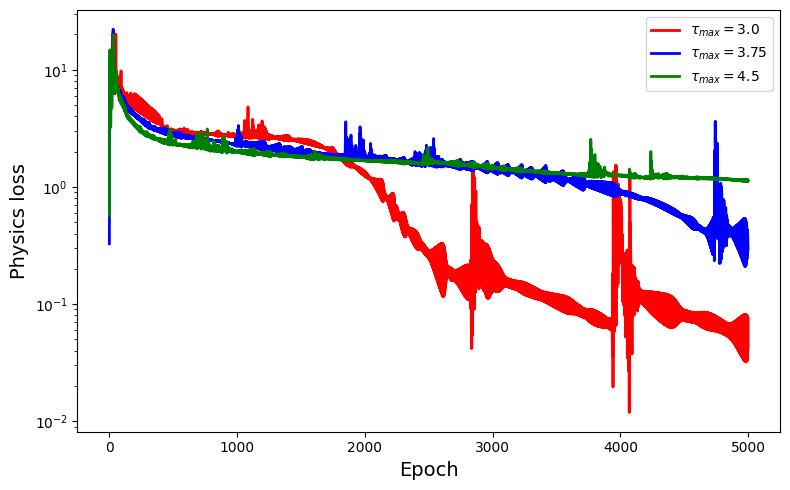

In [ ]:
plt.figure(figsize=(8, 5))

colors = ['red', 'blue', 'green']

for color, tau_max in zip(colors, PERIODS_LIST):

    loss_history = results[tau_max]["loss"]

    epochs = [x["epoch"] for x in loss_history]
    physics_val = [x["physics_val"] for x in loss_history]

    plt.semilogy(
        epochs,
        physics_val,
        color=color,
        lw=2,
        label=fr"$\tau_{{max}}={tau_max}$"
    )

plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Physics loss", fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

## Plotting

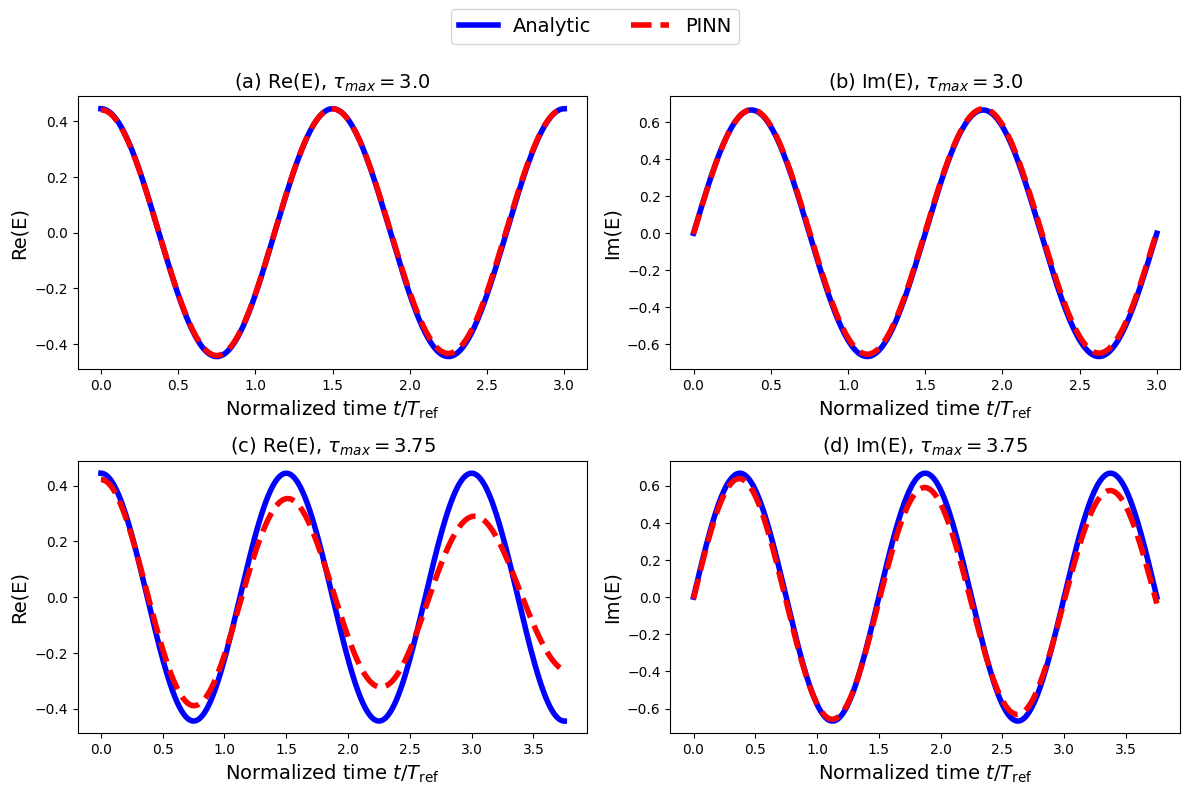

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, tau_max in enumerate(PERIODS_LIST[:2]):

    tau, u_true, u_pred = results[tau_max]["solution"]

    # Real part
    axes[i, 0].plot(
        tau,
        np.real(u_true),
        lw=4,
        label="Analytic", color = 'b',
    )

    axes[i, 0].plot(
        tau,
        np.real(u_pred),
        linestyle="--",
        lw=4,
        label="PINN", color = 'red',
    )

    axes[i, 0].set_title(
        fr"({chr(97 + 2*i)}) Re(E), $\tau_{{max}}={tau_max}$",
        fontsize=14
    )
    axes[i, 0].set_xlabel(r"Normalized time $t/T_{\rm ref}$", fontsize=14)
    axes[i, 0].set_ylabel(r"Re(E)", fontsize=14)

    # Imaginary part
    axes[i, 1].plot(
        tau,
        np.imag(u_true),
        lw=4,
        label="Analytic", color = 'b',
    )

    axes[i, 1].plot(
        tau,
        np.imag(u_pred),
        linestyle="--",
        lw=4,
        label="PINN", color = 'red',
    )

    axes[i, 1].set_title(
        fr"({chr(98 + 2*i)}) Im(E), $\tau_{{max}}={tau_max}$",
        fontsize=14
    )
    axes[i, 1].set_xlabel(r"Normalized time $t/T_{\rm ref}$", fontsize=14)
    axes[i, 1].set_ylabel(r"Im(E)", fontsize=14)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()